# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
rs=42

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split,GridSearchCV,KFold
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder

# Estimators
from sklearn.linear_model import LogisticRegression,Perceptron,SGDClassifier
from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier

# Metrics
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

#Metadata
The dataset contains 5000 records and 14 variables, each described below:

|Column|	Description|
|---|---|
|person_age|	Age of the person|
|person_gender	|Gender of the person	|
|person_education	|Highest education level	|
|person_income	|Annual income	|
|person_emp_exp	|Years of employment experience	|
|person_home_ownership	|Home ownership status (e.g., rent, own, mortgage)	|
|loan_amnt	|Loan amount requested	|
|loan_intent	|Purpose of the loan	|
|loan_int_rate	|Loan interest rate (in %)	|
|loan_percent_income	|Loan amount as a percentage of annual income|
|cb_person_cred_hist_length	|Length of credit history in years	|
|credit_score	|Credit score of the person	|
|previous_loan_defaults_on_file	|Indicator of previous loan defaults	|
|loan_status (target variable)|	Loan approval status: 1 = approved; 0 = rejected|

# Preprocessing

### Q1. [marks : 0] Which dataset are you using for this exam?

Options:

A) MLP_OPPE2_25T2_preprocessing_V1

B) MLP_OPPE2_25T2_preprocessing_V2

C) MLP_OPPE2_25T2_preprocessing_V3

Answer: \
V1: A\
V2: B\
V3: C

- https://drive.google.com/file/d/1gySm-DkXcMoHdsX7aHq6H9II63LlqIRo/view?usp=drive_link

- https://drive.google.com/file/d/15OBfzrWgfov9mNwvc0eHVxsNP1f7iEzB/view?usp=drive_link

- https://drive.google.com/file/d/1kEpat_o5w34xZqeod38PDv5LgPoL78M0/view?usp=drive_link

In [3]:
# @title Load Preprocessing Dataset { form-width: "35%" }
V1= "https://drive.google.com/open?id=1gySm-DkXcMoHdsX7aHq6H9II63LlqIRo&usp=drive_copy"
V2= "https://drive.google.com/open?id=15OBfzrWgfov9mNwvc0eHVxsNP1f7iEzB&usp=drive_copy"
V3= "https://drive.google.com/open?id=1kEpat_o5w34xZqeod38PDv5LgPoL78M0&usp=drive_copy"
id_ind = 33
version = V1 # @param ["V1", "V2", "V3"] {type:"raw"}

In [4]:
dataset = f"https://drive.google.com/uc?id={version[id_ind:id_ind+33]}&export=download"
df = pd.read_csv(dataset)
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,27.0,female,Bachelor,291769.0,8,MORTGAGE,12000.0,MEDICAL,16.64,0.04,6.0,687,No,1
1,25.0,male,Bachelor,61375.0,0,RENT,7200.0,PERSONAL,8.49,0.12,2.0,631,Yes,0
2,22.0,male,Bachelor,51403.0,0,OWN,7000.0,VENTURE,11.01,0.14,3.0,590,NaN,0
3,27.0,male,Bachelor,71968.0,4,RENT,18000.0,MEDICAL,12.42,0.25,9.0,660,No,1
4,27.0,female,High School,29455.0,4,RENT,5214.0,VENTURE,10.04,0.18,5.0,624,Yes,0


In [5]:
df.shape

(5000, 14)

### Q2 [Marks:5] In this dataset, what is the most frequent category in the "person_education" feature?

(A) High School

(B) Bachelor

(C) Associate

(D) Master

(E) Doctorate

All Versions: B

In [6]:
df["person_education"].mode()

,person_education
0,Bachelor


In [7]:
df["person_education"].value_counts()

,count
person_education,
Bachelor,1483
Associate,1343
High School,1326
Master,799
Doctorate,49


###Q3[Marks:5] What is the ratio of counts of individuals with **home_ownership** = "RENT" to those with **home_ownership** = "OWN" among individuals who meet the following criteria:

- person_income > 75 000,
- loan_int_rate > 10%
- previous_loan_defaults_on_file = ‘No’


(A) 180 : 14

(B) 157 : 13

(C) 165 : 16

(D) 98 : 11

V1: A\
V2: B\
V3: C

In [59]:
mask = ((df['person_income'] > 75_000) &
        (df['loan_int_rate'] > 10) &
        (df['previous_loan_defaults_on_file'] == 'No'))
filtered = df.loc[mask]
counts = filtered['person_home_ownership'].value_counts()
own_count  = counts.get('OWN',  0)
rent_count = counts.get('RENT', 0)
ratio = f'{rent_count} : {own_count}'
print(ratio)

180 : 14


In [9]:
mask = ((df['person_income'] > 75_000) &
    (df['loan_int_rate']   > 10)    &
    (df['previous_loan_defaults_on_file'] == 'No'))
filtered = df.loc[mask]
counts = filtered['person_home_ownership'].value_counts()
own_count  = counts.get('OWN',  0)
rent_count = counts.get('RENT', 0)

print(f"OWN count: {own_count}")
print(f"RENT count: {rent_count}")
print(f"Ratio (RENT : OWN) = {rent_count}: {own_count}")

OWN count: 14
RENT count: 180
Ratio (RENT : OWN) = 180: 14


###Q4[Marks:5] Which of the following option(s) are true?
(A) Average **person_income** for person_education = Bachelor falls within the range of 60000 to 70000.

(B) Average **person_income** for person_education = Master falls within the range of 75000 to 85000.

(C) Average **person_income** for person_education = Associate falls within the range of 75000 to 85000.

(D) Average **person_income** for person_education = High School falls within the range of 40000 to 50000.

(E) None of these

All versions: B,C

In [10]:
df.pivot_table(values='person_income', index='person_education', aggfunc='mean')

,person_income
person_education,
Associate,80956.843548
Bachelor,79296.854197
Doctorate,75674.956522
High School,78423.555102
Master,82798.866941


### Q5.[Marks: 5] Create feature matrix(X) and label vector(y) using following instructions:
- `loan_status` is the target column(y).
- All the columns except the target column are in feature matrix(X).

Compare the correlation value for the following feature pairs of feature matrix(X) and select the option which has the highest positive value .

(A) **loan_amnt** vs **loan_percent_income**

(B) **person_income** vs **loan_percent_income**

(C) **credit_score** vs **loan_int_rate**

(D) **person_age** vs **credit_score**

(E) **cb_person_cred_hist_length** vs **person_emp_exp**


All Versions: E


In [11]:
print("A:", df['loan_amnt'].corr(df['loan_percent_income']))
print("B:", df['person_income'].corr(df['loan_percent_income']))
print("C:", df['credit_score'].corr(df['loan_int_rate']))
print("D:", df['person_age'].corr(df['credit_score']))
print("E:", df['cb_person_cred_hist_length'].corr(df['person_emp_exp']))

A: 0.5863986962098241
B: -0.2942165641449565
C: 0.03214035444639199
D: 0.1469470657839648
E: 0.8189375363423236


### Q6 [Marks 5] Split the dataset into train dataset and test dataset in the following manner.

- Use sklearn train_test_split function to split the data.
- Use only 20% data as test_set and keep random_state = 24

What is the sum of `loan_status`(target) column in test_set?

V1: 229\
V2: 231\
V3: 221

In [12]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
y_test.sum()

np.int64(229)

### All the following questions are related to **Data Preprocessing**. You have to apply, save the preprocessing steps and move further.

## Common Instructions for Question 7 to 9
## Rules for Imputing the missing(NaN) or Unknown values:
- Calculating statistical values (such as mean, median, mode) for each column in the training dataset.
- Applying these calculated statistical values to replace missing (NaN) and unknown values in both the training and test datasets.
- Ensuring that the calculation of statistical values excludes any rows containing missing or unknown values.
- After imputation store the dataframe in another variable imputed_df

- Replace the missing values in the **person_age** feature with the **Mean** value in that.
- Replace the missing values in the **loan_int_rate** feature with the **Mean** value in that.

- Replace the missing values in the **person_income** feature with the **Median** value in that.

- Replace the missing values in the **person_home_ownership** feature with the **Constant** value 'OTHER'. (case sensitive)

- Replace the missing values in the **previous_loan_defaults_on_file** feature with the **Constant** value 'No'. (case sensitive)


- Write the answers related to the above imputation in below questions respectively.


In [14]:
X_train.isnull().sum()

,0
person_age,306
person_gender,0
person_education,0
person_income,325
person_emp_exp,0
person_home_ownership,331
loan_amnt,0
loan_intent,0
loan_int_rate,319
loan_percent_income,0


In [15]:
transformer_list = [
    ('mean',SimpleImputer(strategy= 'mean'),['person_age','loan_int_rate'] ),
    ('median',SimpleImputer(strategy= 'median'),['person_income'] ),
    ('constant1', SimpleImputer(strategy= 'constant',fill_value="OTHER"), ['person_home_ownership']),
    ('constant2', SimpleImputer(strategy= 'constant',fill_value="No"), ['previous_loan_defaults_on_file']),
]

ct = ColumnTransformer(transformers = transformer_list, remainder='passthrough',verbose_feature_names_out=False).set_output(transform="pandas")
ct

ColumnTransformer(remainder='passthrough',
                  transformers=[('mean', SimpleImputer(),
                                 ['person_age', 'loan_int_rate']),
                                ('median', SimpleImputer(strategy='median'),
                                 ['person_income']),
                                ('constant1',
                                 SimpleImputer(fill_value='OTHER',
                                               strategy='constant'),
                                 ['person_home_ownership']),
                                ('constant2',
                                 SimpleImputer(fill_value='No',
                                               strategy='constant'),
                                 ['previous_loan_defaults_on_file'])],
                  verbose_feature_names_out=False)

In [16]:
X_train_impute = ct.fit_transform(X_train)
X_test_impute = ct.transform(X_test)

In [17]:
X_train_impute.isnull().sum()

,0
person_age,0
loan_int_rate,0
person_income,0
person_home_ownership,0
previous_loan_defaults_on_file,0
person_gender,0
person_education,0
person_emp_exp,0
loan_amnt,0
loan_intent,0


In [18]:
X_test_impute.isnull().sum()

,0
person_age,0
loan_int_rate,0
person_income,0
person_home_ownership,0
previous_loan_defaults_on_file,0
person_gender,0
person_education,0
person_emp_exp,0
loan_amnt,0
loan_intent,0


### Q7 [Marks: 5] Write the MEAN value of the **person_income** column of the train dataset after you have replaced all the Missing Values (NaN). [NAT] (upto 2 digits after decimal points)

V1: 78260.73 (Range: 78250 - 78300)

V2: 78571.56 (Range: 78550 - 78600)

V3: 82829.08 (Range: 82800 - 82850)

In [19]:
X_train_impute['person_income'].mean()

np.float64(78260.7275)

### Q8 [Marks: 5] Write the MEAN value of the loan_int_rate column of the train dataset you found to replace all the Missing Values (NaN). [NAT] (correct upto 2 digits after decimal points)

V1: 11.12 (Range: 11.00, 11.20)

V2: 11.01 (Range: 10.90, 11.10)

V3: 10.97 (Range: 10.90, 11.10)

In [20]:
X_train['loan_int_rate'].mean()

np.float64(11.119606085302907)

### Q9 [Marks: 5] Write the MOST FREQUENT value of the **person_home_ownership** column of the train dataset after replacing all the Missing Values (NaN) with constant.

(A) MORTGAGE

(B) OWN

(C) OTHER

(D) RENT

All versions: D


In [21]:
X_train_impute["person_home_ownership"].value_counts()

,count
person_home_ownership,
RENT,1855
MORTGAGE,1561
OTHER,340
OWN,244


## Apply preprocessing on features of train and test datasets.

- After applying the above imputation steps there should not be any missing or unknown values present in the train and test dataset.

- Fitting (learning) should be done only on train dataset after above imputation is done.

- Learn transformers' parameters using training set only and then apply them on train & test sets.

## For Categorical Features

Ordinally Encode **"person_education"** features as Order given in table below

|person_education|Order|
|-------|--------|
|High School|0|
|Associate|1|
|Bachelor|2|
|Master|3|
|Doctorate|4|

### Nominal Features
- One-Hot Encode **"person_gender", "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file"** features with sparse_output = False and drop = 'first'


### Scaling Features
* Scale **all the features** (transformed categorical and numerical) of the feature matrix using the **StandardScaler**

In [22]:
trf = [
    ("OE",OrdinalEncoder(categories=[['High School','Associate','Bachelor', 'Master', 'Doctorate']]),["person_education"]),
    ("OHE",OneHotEncoder(sparse_output=False ,drop = 'first'),["person_gender", "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file"])
]

ct2 = ColumnTransformer(trf, remainder='passthrough',verbose_feature_names_out=False).set_output(transform="pandas")

ct2


ColumnTransformer(remainder='passthrough',
                  transformers=[('OE',
                                 OrdinalEncoder(categories=[['High School',
                                                             'Associate',
                                                             'Bachelor',
                                                             'Master',
                                                             'Doctorate']]),
                                 ['person_education']),
                                ('OHE',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['person_gender', 'person_home_ownership',
                                  'loan_intent',
                                  'previous_loan_defaults_on_file'])],
                  verbose_feature_names_out=False)

In [23]:
X_train_encode = ct2.fit_transform(X_train_impute)
X_test_encode = ct2.transform(X_test_impute)

In [24]:
X_train_encode

,person_education,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,person_age,loan_int_rate,person_income,person_emp_exp,loan_amnt,loan_percent_income,cb_person_cred_hist_length,credit_score
4047,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.000000,13.850000,104910.0,0,24000.0,0.23,2.0,632
2853,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,27.723335,9.010000,725550.0,4,25000.0,0.03,9.0,604
1749,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,30.000000,9.520000,47298.0,6,5000.0,0.11,7.0,649
1538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,24.000000,11.010000,85089.0,2,12000.0,0.14,2.0,581
2669,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,21.000000,12.860000,31100.0,0,5000.0,0.16,2.0,642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,22.000000,11.119606,54783.0,2,3000.0,0.05,4.0,664
3473,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,24.000000,10.990000,174801.0,3,7000.0,0.04,3.0,706
343,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,29.000000,7.450000,88637.0,10,12000.0,0.14,8.0,622
899,3.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,26.000000,9.640000,66699.0,6,25000.0,0.43,4.0,686


In [25]:
ss = StandardScaler().set_output(transform="pandas")
X_train_ss = ss.fit_transform(X_train_encode)
X_test_ss = ss.transform(X_test_encode)

In [26]:
X_train_ss

,person_education,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,person_age,loan_int_rate,person_income,person_emp_exp,loan_amnt,loan_percent_income,cb_person_cred_hist_length,credit_score
4047,-1.302363,0.910029,-0.304789,-0.254878,-0.929947,-0.482354,-0.345245,-0.491783,2.171241,-0.449760,-0.970437,-0.992182,0.970028,0.418605,-0.895187,2.364960,1.073437,-0.998138,-0.003111
2853,1.509504,-1.098866,-0.304789,-0.254878,-0.929947,-0.482354,-0.345245,-0.491783,2.171241,-0.449760,-0.970437,0.000000,-0.749480,10.167574,-0.230238,2.526754,-1.260439,0.826254,-0.554490
1749,-0.365074,-1.098866,-0.304789,-0.254878,1.075330,2.073165,-0.345245,-0.491783,-0.460566,-0.449760,-0.970437,0.394677,-0.568293,-0.486360,0.102236,-0.709114,-0.326888,0.304999,0.331655
1538,-1.302363,-1.098866,-0.304789,-0.254878,-0.929947,-0.482354,-0.345245,-0.491783,-0.460566,2.223406,1.030464,-0.645467,-0.038940,0.107258,-0.562713,0.423440,0.023193,-0.998138,-1.007409
2669,-0.365074,0.910029,-0.304789,-0.254878,1.075330,-0.482354,-0.345245,-0.491783,-0.460566,-0.449760,-0.970437,-1.165539,0.618310,-0.740797,-0.895187,-0.709114,0.256580,-0.998138,0.193810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,-0.365074,-1.098866,-0.304789,-0.254878,-0.929947,2.073165,-0.345245,-0.491783,-0.460566,-0.449760,1.030464,-0.992182,0.000000,-0.368786,-0.562713,-1.032700,-1.027051,-0.476883,0.627036
3473,-1.302363,-1.098866,-0.304789,-0.254878,-0.929947,-0.482354,2.896493,-0.491783,-0.460566,-0.449760,1.030464,-0.645467,-0.046045,1.516448,-0.396476,-0.385527,-1.143745,-0.737510,1.454105
343,-1.302363,-1.098866,-0.304789,-0.254878,-0.929947,2.073165,-0.345245,-0.491783,-0.460566,-0.449760,1.030464,0.221319,-1.303702,0.162990,0.767184,0.423440,0.023193,0.565627,-0.200032
899,1.509504,-1.098866,3.280961,-0.254878,-0.929947,2.073165,-0.345245,-0.491783,-0.460566,-0.449760,-0.970437,-0.298753,-0.525660,-0.181611,0.102236,2.526754,3.407313,-0.476883,1.060263


###Q10 [Marks:3][NAT] Calculate the sum of all the values present in the transformed train feature matrix ? (upto 2 digits afer the decimal)

All versions: 0 (Range: -0.10, 0.10)

In [27]:
X_train_ss.values.sum()

np.float64(2.4868995751603507e-13)

###Q11 [Marks:7][NAT] Calculate the sum of all the values present in the transformed test feature matrix ? (upto 2 digits afer the decimal)

V1: -71.63 (Range: -75, -65)

V2: 90.88 (Range: 85, 95)

V3: -317.13 (Range: -320, -310)


In [28]:
X_test_ss.values.sum()

np.float64(-71.62527093435313)

In [29]:
pp_marks = {"Q1":0,
            "Q2":5,
            "Q3":5,
            "Q4":5,
            "Q5":5,
            "Q6":5,
            "Q7":5,
            "Q8":5,
            "Q9":5,
            "Q10":3,
            "Q11":7}
sum(pp_marks.values())

50

In [30]:
train = pd.concat((X_train_ss,y_train),axis=1)
test = pd.concat((X_test_ss,y_test),axis=1)
mb_data = pd.concat((train,test))
mb_data

,person_education,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,person_age,loan_int_rate,person_income,person_emp_exp,loan_amnt,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
4047,-1.302363,0.910029,-0.304789,-0.254878,-0.929947,-0.482354,-0.345245,-0.491783,2.171241,-0.449760,-0.970437,-0.992182,0.970028,0.418605,-0.895187,2.364960,1.073437,-0.998138,-0.003111,0
2853,1.509504,-1.098866,-0.304789,-0.254878,-0.929947,-0.482354,-0.345245,-0.491783,2.171241,-0.449760,-0.970437,0.000000,-0.749480,10.167574,-0.230238,2.526754,-1.260439,0.826254,-0.554490,1
1749,-0.365074,-1.098866,-0.304789,-0.254878,1.075330,2.073165,-0.345245,-0.491783,-0.460566,-0.449760,-0.970437,0.394677,-0.568293,-0.486360,0.102236,-0.709114,-0.326888,0.304999,0.331655,0
1538,-1.302363,-1.098866,-0.304789,-0.254878,-0.929947,-0.482354,-0.345245,-0.491783,-0.460566,2.223406,1.030464,-0.645467,-0.038940,0.107258,-0.562713,0.423440,0.023193,-0.998138,-1.007409,0
2669,-0.365074,0.910029,-0.304789,-0.254878,1.075330,-0.482354,-0.345245,-0.491783,-0.460566,-0.449760,-0.970437,-1.165539,0.618310,-0.740797,-0.895187,-0.709114,0.256580,-0.998138,0.193810,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1644,0.572215,-1.098866,-0.304789,-0.254878,1.075330,-0.482354,2.896493,-0.491783,-0.460566,-0.449760,1.030464,0.000000,-0.134863,0.202150,-0.230238,-0.385527,-0.676970,-0.737510,0.469499,0
4329,-0.365074,-1.098866,3.280961,-0.254878,-0.929947,2.073165,-0.345245,-0.491783,-0.460566,-0.449760,-0.970437,1.434820,-0.038940,1.235339,1.764607,1.717787,-0.093501,2.129391,0.922418,0
1137,1.509504,0.910029,-0.304789,-0.254878,1.075330,-0.482354,-0.345245,2.033418,-0.460566,-0.449760,-0.970437,0.047962,0.554362,-0.162793,0.102236,-0.624172,-0.676970,0.826254,0.410423,0
1493,0.572215,-1.098866,-0.304789,-0.254878,1.075330,-0.482354,-0.345245,-0.491783,-0.460566,2.223406,1.030464,0.741391,-1.282386,-0.720691,0.600947,-0.223734,1.306824,1.086881,0.233194,0


In [31]:
mb_data.shape

(5000, 20)

#ModelBuilding [Marks: 50]

## Instruction
- **Set or change** the parameters specified in the question, while keeping all other parameters at their default values.

### Q1. [marks : 0] Which dataset are you using for this Model Building section? The dataset should have 5000 rows.

Options:

(A) MLP_OPPE2_25T2_modelBuilding_V1

(B) MLP_OPPE2_25T2_modelBuilding_V2

(C) MLP_OPPE2_25T2_modelBuilding_V3


Answer:\
V1: A\
V2: B\
V3: C

In [32]:
# @title Load model building Dataset {"form-width":"50%"}
V1= "https://drive.google.com/open?id=1U5-xwF06mL9nJ4VIQuCfuV0iL9G_WhiZ&usp=drive_copy"
V2 = "https://drive.google.com/open?id=1ipF9C9o8lw69wmW-7GgcUcKqjSVJ05ox&usp=drive_copy"
V3= "https://drive.google.com/open?id=1A1O_psrWu8Prw8y3VsIcwtsQB1CGn_vV&usp=drive_copy"
id_ind = 33
version = V3 # @param ["V1", "V2", "V3"] {type:"raw"}
dataset_mb = f"https://drive.google.com/uc?id={version[id_ind:id_ind+33]}&export=download"

df_mb = pd.read_csv(dataset_mb)

In [33]:
df_mb.head()

,person_education,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,person_age,loan_int_rate,person_income,person_emp_exp,loan_amnt,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,0.562938,0.890459,-0.28269,-0.244711,1.035116,-0.514026,-0.356034,-0.473672,2.184492,-0.441297,-0.945958,-0.850943,1.438302,-0.716172,-0.415325,-1.033770,-0.672829,-0.483654,0.362732,0
1,0.562938,0.890459,-0.28269,-0.244711,1.035116,-0.514026,-0.356034,-0.473672,2.184492,-0.441297,-0.945958,0.583368,-1.127409,0.092176,0.100340,-0.858278,-1.018446,0.304270,-1.782523,1
2,0.562938,-1.123016,-0.28269,4.086455,-0.966075,-0.514026,-0.356034,2.111167,-0.457772,-0.441297,-0.945958,-0.671655,2.843090,0.566790,-0.587214,0.078952,-0.557624,-1.008936,0.362732,1
3,1.497275,0.890459,-0.28269,-0.244711,-0.966075,1.945428,-0.356034,-0.473672,-0.457772,-0.441297,-0.945958,0.224790,-1.069020,1.120923,-0.071549,4.052962,1.170460,0.566911,0.799728,0
4,0.562938,0.890459,-0.28269,-0.244711,-0.966075,1.945428,-0.356034,-0.473672,-0.457772,-0.441297,1.057129,-0.850943,0.401027,-0.198758,-0.759102,0.078952,-0.096801,-0.483654,-0.829076,0


### Split the dataset into train dataset and test dataset in the following manner.
- **loan_status** is the target column(y).
- All the columns except the target column are in feature matrix(X).
- Use sklearn train_test_split function to split the data.
- Use only 20% data as test_set and keep random_state = 42

In [34]:
X_mb = df_mb.drop('loan_status', axis=1)
y_mb = df_mb['loan_status']

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(X_mb,y_mb,test_size=0.2,random_state=rs)

In [36]:
X_tr.shape

(4000, 19)

In [37]:
X_tr.columns

Index(['person_education', 'person_gender_male', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'previous_loan_defaults_on_file_Yes', 'person_age', 'loan_int_rate',
       'person_income', 'person_emp_exp', 'loan_amnt', 'loan_percent_income',
       'cb_person_cred_hist_length', 'credit_score'],
      dtype='object')

### Q2 [5 marks][NAT] Take **`LogisticRegression`** estimator with following parameters for training:
  - Use `sag` as solver
  - Set random state to be equal to 42
  - Tolerance for stopping criteria to be 1e-3
  - Maximum number of iterations taken for the solvers to converge to be 300

### **Enter the number of iteration required for the given model to converge using train set (X_train, y_train)**

V1: 77

V2: 52

V3: 191

In [38]:
logistic = LogisticRegression(solver='sag',
                              tol=1e-3,
                              max_iter=300,
                              random_state =rs)
logistic.fit(X_tr, y_tr)

logistic.n_iter_

array([191], dtype=int32)

### Q3  [6 marks] [NAT] Use **`SGDClassifier`** on the training dataset (**`X_train`** and **`y_train`**) to train the model. Use the following parameters:

1. `log_loss`is the loss function to be used
2. apply ridge regularization,
3. maximum number of passes over the training data is 30
4. Initial learning rate of 0.01
5. regularization rate value is 0.001,
6. Take random_state=42.
7. Set warm_start as True

Note : Please ignore the convergence warning.

### **Using above model, calculate and write the correct value of f1_score for label class = 0 of the test set.**

V1: 0.92 (Range: 0.91, 0.93)

V2: 0.92 (Range: 0.91, 0.93)

V3: 0.92 (Range: 0.91, 0.93)

In [39]:
logistic_sgd = SGDClassifier(loss='log_loss',
                        penalty='l2',
                        max_iter=30,
                        warm_start=True,
                        eta0=0.01,
                        alpha=0.001,
                        random_state=rs)

logistic_sgd.fit(X_tr,y_tr)

y_pred = logistic_sgd.predict(X_te)
f1_score(y_te, y_pred, pos_label=0)

0.9227848101265823

In [40]:
print(classification_report(y_te,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       789
           1       0.71      0.71      0.71       211

    accuracy                           0.88      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.88      0.88      0.88      1000



### Q4. [6 marks] [MCQ] For the training dataset tune the parameters using Gridsearchcv for below settings  
- `estimator = KNeighborsClassifier`
- `scoring =accuracy`
- `cv= 5`
* Consider following parameters for KNeighborsClassifier:
 - `n_neighbors = [11,17,23,29]`
 - `metric = "minkowski"`
 - Set p value for `minkowski = 2`

- Keep other parameter values as default values.

### **What is the best value of K you obtained using the above instructions?**

Options

(A) 11

(B) 17

(C) 23

(D) 29

Ans:

V1: C

V2: C

V3: B

In [41]:
knn_clf = KNeighborsClassifier(metric = 'minkowski', p = 2)

gs_cv = GridSearchCV(knn_clf,
                  param_grid= {'n_neighbors':[11,17,23,29]},
                  scoring='accuracy',
                  cv=5)

gs_cv.fit(X_tr,y_tr)
gs_cv.best_params_

{'n_neighbors': 17}

###Q.5 [3 Marks] [MCQ] Fit an SVM classifier (SVC) with the following parameters:

- `kernel='rbf'`
- `decision_function_shape='ovr'`
- `random_state=42`  
- `C=1`

###**Train the model on training data, and choose the option with the correct classification confusion matrix on test data.**

(A)$\begin{bmatrix} %V2
 754  & 39\\
 64 & 143
 \end{bmatrix}$
\
\
(B) $\begin{bmatrix} %V1
 744  & 38\\
 79 & 139
 \end{bmatrix}$
\
\
(C) $\begin{bmatrix} %
1523 & 69 \\
142 & 266
 \end{bmatrix}$
\
\
(D)$\begin{bmatrix} %V3
 748 &  41\\
 68 & 143
 \end{bmatrix}$
\
\
(E) None of the above

**Answers**

V1: B

V2: A

V3: D


In [42]:
svc =  SVC(kernel='rbf',
           decision_function_shape='ovr',
           C=1,
           random_state=rs)

svc.fit(X_tr,y_tr)


y_pred = svc.predict(X_te)

cm = confusion_matrix(y_te, y_pred)
print('Confusion matrix : \n', cm)


Confusion matrix : 
 [[748  41]
 [ 68 143]]


**Common Instruction for Question 6 to 8**

Train a Decision Tree Classifier on the training data with the following parameters:

- `criterion = 'entropy'`
- `splitter = 'random'`
- `min_samples_split = 3`
- `min_impurity_decrease = 0.0001`
- `random_state = 42`

###**Q.6 [MCQ][3 Marks] What is the maximum depth of the trained Decision Tree?**

V1 : 26

V2 : 25

V3 : 23

In [43]:
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier(criterion = 'entropy',
                                  splitter = 'random',
                                  min_samples_split = 3,
                                  min_impurity_decrease = 0.0001,
                                  random_state = rs)
model_DT.fit(X_tr, y_tr)

DecisionTreeClassifier(criterion='entropy', min_impurity_decrease=0.0001,
                       min_samples_split=3, random_state=42, splitter='random')

In [44]:
model_DT.get_depth()

23

###**Q.7 [NAT][3 Marks] How many leaf nodes does the trained Decision Tree have?**
V1: 488

V2: 482

V3: 471

In [45]:
sum(model_DT.tree_.children_left == -1)

np.int64(471)

###**Q.8 [NAT][5 Marks] What is the impurity (entropy) at the root node of the trained Decision Tree?** (correct upto 2 digit after decimal)

V1: 0.76 (Range: 0.75 , 0.77)

V2: 0.78 (Range: 0.76 , 0.78)

V3: 0.76 (Range: 0.75 , 0.77)

In [46]:
model_DT.tree_.impurity[0]

np.float64(0.7624434069014199)

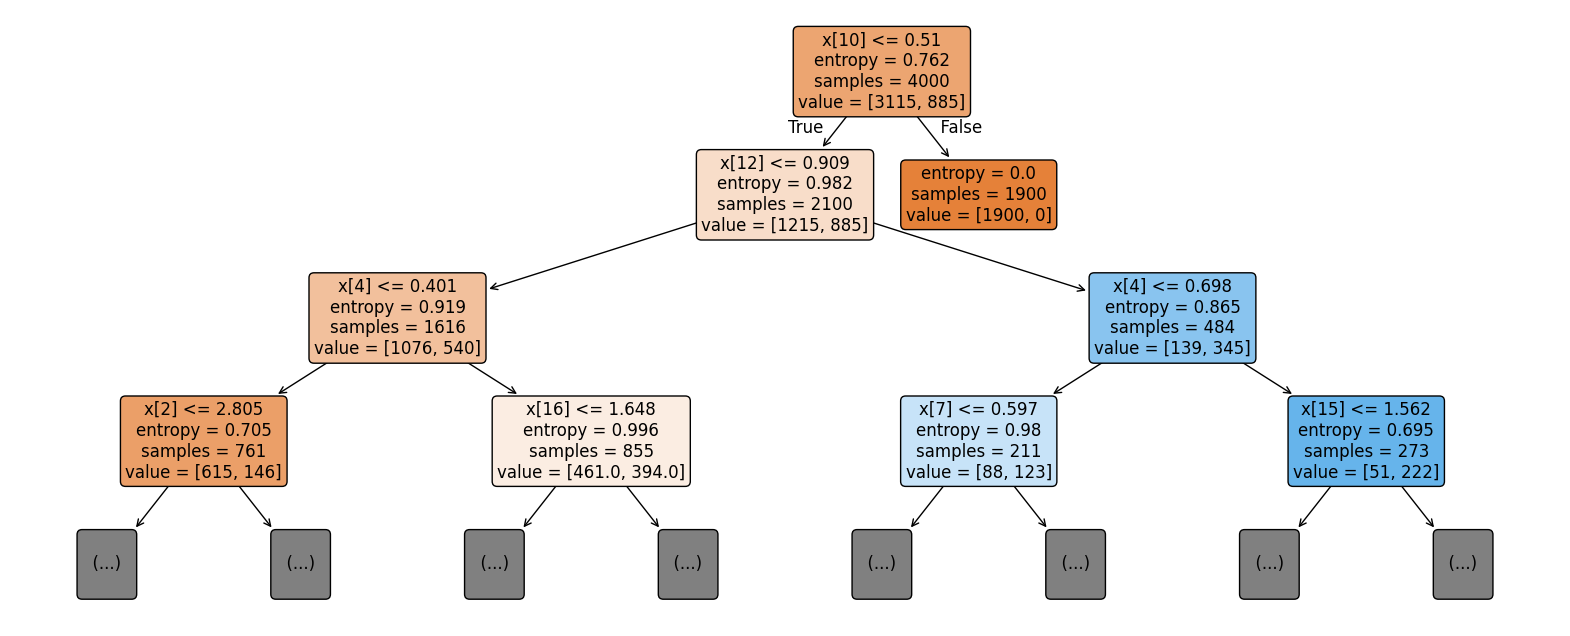

In [47]:
from sklearn import tree

plt.figure(figsize=(20,8), facecolor ='w')

# feature_names = df.feature_names
#create the tree plot
tree.plot_tree(model_DT,
                       #use the feature names stored
                   #feature_names = feature_names,
                   #use the class names stored
               rounded = True,
               max_depth = 3,
               filled = True,
               fontsize=12)
#show the plot
plt.show()

### **(Common Instructions for Q9,Q10)**
Train an AdaBoost Classifier model on the training data using the specified hyperparameter values below and optimize it with GridSearchCV

- Use n_estimators as [13,29,37]
- random_state = 42
- Use learning_rate as [0.001,0.01,1,2]
- use 5 fold cross validation




In [48]:
params = {'n_estimators':[13,29,37],
          'learning_rate':[0.001,0.01,1,2]}
adc = AdaBoostClassifier(random_state = rs)
gscv_ab = GridSearchCV(adc,
                       params,
                       cv=5)

gscv_ab.fit(X_tr, y_tr)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
             param_grid={'learning_rate': [0.001, 0.01, 1, 2],
                         'n_estimators': [13, 29, 37]})

### Q9[Marks: 5][MCQ]
**After training the AdaBoost model using GridSearchCV with the specified hyperparameters. Choose the value of learning_rate of the best model selected by GridSearchCV.**

Options:

(A) 0.001

(B) 0.01

(C) 1

(D) 2

**Answer**

All versions: C

In [49]:
gscv_ab.best_params_

{'learning_rate': 1, 'n_estimators': 29}

###**Q10[Marks: 5] [NAT] Train the 'model' using the above instructions and use the best estimator to calculate the total number of misclassified samples in test data for which the true label was 0 (i.e. y_test=0) and submit the value.**

Answer:

V1: 39  

V2: 30  

V3: 60

In [50]:
cm = confusion_matrix(y_te, gscv_ab.best_estimator_.predict(X_te))
cm[0,1]

np.int64(60)

In [51]:
cm

array([[729,  60],
       [ 63, 148]])

### Q11. [Marks: 5 ] [NAT] Train  with RandomizedSearchCV.

- Keep Below Settings for **`RandomForestClassifier(random_state=42)`** estimator
  - n_estimators = range(2,100)
  - max_depth = range(1,11)
  - min_impurity_decrease = uniform(loc=0,scale=5)


- Keep below settings for RandomizedSearchCV
  - estimator = RandomForestClassifier(random_state=42)
  - random_state = 42
  - n_iter=5
  - cv=3
  - n_jobs= -1
  - verbose=2

hint: from scipy.stats import uniform

###**Submit the best param value for n_estimators using this RandomizedSearchCV on train data.**

**Answer**

V1: 16

V2: 16

V3: 16

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

In [53]:
param_grid = {
    'n_estimators': range(2,100),
    'max_depth': range(1,11),
    'min_impurity_decrease': uniform(loc=0,scale=5)
}

rf_gs = RandomizedSearchCV(RandomForestClassifier(random_state=rs),
                           param_distributions = param_grid,
                           random_state=rs,
                           n_iter=5,
                           cv=3,
                           verbose=2,
                           n_jobs=-1,
                           )
rf_gs.fit(X_tr,y_tr)

rf_gs.best_params_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


{'max_depth': 7,
 'min_impurity_decrease': np.float64(3.982714934301164),
 'n_estimators': 16}

In [54]:
rf_gs.best_params_["n_estimators"]

16

In [55]:
rf_gs.cv_results_["params"]

[{'max_depth': 7,
  'min_impurity_decrease': np.float64(3.982714934301164),
  'n_estimators': 16},
 {'max_depth': 8,
  'min_impurity_decrease': np.float64(2.993292420985183),
  'n_estimators': 84},
 {'max_depth': 7,
  'min_impurity_decrease': np.float64(0.2904180608409973),
  'n_estimators': 89},
 {'max_depth': 5,
  'min_impurity_decrease': np.float64(3.005575058716044),
  'n_estimators': 25},
 {'max_depth': 3,
  'min_impurity_decrease': np.float64(0.10292247147901223),
  'n_estimators': 3}]

In [56]:
pd.DataFrame(rf_gs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_impurity_decrease,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.054428,0.001889,0.006136,0.000042,7,3.982715,16,"{'max_depth': 7, 'min_impurity_decrease': 3.98...",0.778861,0.778695,0.778695,0.77875,0.000078,1
1,0.265790,0.013927,0.014712,0.000856,8,2.993292,84,"{'max_depth': 8, 'min_impurity_decrease': 2.99...",0.778861,0.778695,0.778695,0.77875,0.000078,1
2,0.258340,0.014020,0.014881,0.000363,7,0.290418,89,"{'max_depth': 7, 'min_impurity_decrease': 0.29...",0.778861,0.778695,0.778695,0.77875,0.000078,1
3,0.075715,0.001249,0.006703,0.000337,5,3.005575,25,"{'max_depth': 5, 'min_impurity_decrease': 3.00...",0.778861,0.778695,0.778695,0.77875,0.000078,1
4,0.013409,0.000580,0.003498,0.000148,3,0.102922,3,"{'max_depth': 3, 'min_impurity_decrease': 0.10...",0.778861,0.778695,0.778695,0.77875,0.000078,1


###**Q12[Marks 4] [NAT] Write the accuray score of the test dataset using the best model** (upto 3 digit after the decimal)

**Answers**

V1: 0.782 (Range: 0.780 , 0.784)

V2: 0.793 (Range: 0.791 , 0.795)

V3: 0.789 (Range: 0.787 , 0.791)

In [57]:
rf_gs.best_estimator_.score(X_te,y_te)

0.789

In [58]:
mb_marks = {"Q1":0,
            "Q2":5,
            "Q3":6,
            "Q4":6,
            "Q5":3,
            "Q6":3,
            "Q7":3,
            "Q8":5,
            "Q9":5,
            "Q10":5,
            "Q11":5,
            "Q12":4,
            }
sum(mb_marks.values())

50